In [ ]:
!pip install torch torchvision torchaudio -U

In [73]:
import os
import torch
# from data import create_dataset
from model import create_model
# from util.visualizer import save_images
# from util import html
import matplotlib.pyplot as plt
import argparse
# from util.util import print_accuracies

In [19]:
parser = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter)
# basic parameters
parser.add_argument('--dataroot', default='datasets/', help='path to images (should have subfolders trainA, trainB, valA, valB, etc)')
parser.add_argument('--datatype', default='text', help='type of dataset (image dataset have subfolders, text dataset has files)')
parser.add_argument('--name', type=str, default='experiment_name', help='name of the experiment. It decides where to store samples and models')
parser.add_argument('--gpu_ids', type=str, default='0', help='gpu ids: e.g. 0  0,1,2, 0,2. use -1 for CPU')
parser.add_argument('--checkpoints_dir', type=str, default='./checkpoints', help='models are saved here')
# model parameters
parser.add_argument('--model', type=str, default='cycle_gan', help='chooses which model to use. [cycle_gan | pix2pix | test | colorization]')
parser.add_argument('--input_nc', type=int, default=3, help='# of input image channels: 3 for RGB and 1 for grayscale')
parser.add_argument('--output_nc', type=int, default=3, help='# of output image channels: 3 for RGB and 1 for grayscale')
parser.add_argument('--ngf', type=int, default=64, help='# of gen filters in the last conv layer')
parser.add_argument('--ndf', type=int, default=64, help='# of discrim filters in the first conv layer')
parser.add_argument('--netD', type=str, default='basic', help='specify discriminator architecture [basic | n_layers | pixel]. The basic model is a 70x70 PatchGAN. n_layers allows you to specify the layers in the discriminator')
parser.add_argument('--netG', type=str, default='resnet_9blocks', help='specify generator architecture [resnet_9blocks | resnet_6blocks | unet_256 | unet_128 | dense | transformer]')
parser.add_argument('--n_layers_D', type=int, default=3, help='only used if netD==n_layers')
parser.add_argument('--norm', type=str, default='instance', help='instance normalization or batch normalization [instance | batch | none]')
parser.add_argument('--init_type', type=str, default='normal', help='network initialization [normal | xavier | kaiming | orthogonal]')
parser.add_argument('--init_gain', type=float, default=0.02, help='scaling factor for normal, xavier and orthogonal.')
parser.add_argument('--no_dropout', action='store_true', help='no dropout for the generator')
# dataset parameters
parser.add_argument('--dataset_mode', type=str, default='unaligned', help='chooses how datasets are loaded. [unaligned | aligned | single | colorization | unalignedpaired]')
parser.add_argument('--direction', type=str, default='AtoB', help='AtoB or BtoA')
parser.add_argument('--serial_batches', action='store_true', help='if true, takes images in order to make batches, otherwise takes them randomly')
parser.add_argument('--num_threads', default=4, type=int, help='# threads for loading data')
parser.add_argument('--batch_size', type=int, default=1, help='input batch size')
parser.add_argument('--load_size', type=int, default=286, help='scale images to this size')
parser.add_argument('--crop_size', type=int, default=256, help='then crop to this size')
parser.add_argument('--max_dataset_size', type=int, default=float("inf"), help='Maximum number of samples allowed per dataset. If the dataset directory contains more than max_dataset_size, only a subset is loaded.')
parser.add_argument('--preprocess', type=str, default='resize_and_crop', help='scaling and cropping of images at load time [resize_and_crop | crop | scale_width | scale_width_and_crop | none]')
parser.add_argument('--no_flip', action='store_true', help='if specified, do not flip the images for data augmentation')
parser.add_argument('--display_winsize', type=int, default=256, help='display window size for both visdom and HTML')
# additional parameters
parser.add_argument('--epoch', type=str, default='latest', help='which epoch to load? set to latest to use latest cached model')
parser.add_argument('--load_iter', type=int, default='0', help='which iteration to load? if load_iter > 0, the code will load models by iter_[load_iter]; otherwise, the code will load models by [epoch]')
parser.add_argument('--suffix', default='', type=str, help='customized suffix: opt.name = opt.name + suffix: e.g., {model}_{netG}_size{load_size}')
parser.add_argument('--results_dir', type=str, default='./results/', help='saves results here.')
parser.add_argument('--aspect_ratio', type=float, default=1.0, help='aspect ratio of result images')
parser.add_argument('--phase', type=str, default='test', help='train, val, test, etc')
# Dropout and Batchnorm has different behavioir during training and test.
parser.add_argument('--eval', action='store_true', help='use eval mode during test time.')
parser.add_argument('--num_test', type=int, default=249, help='how many test images to run')

opt = parser.parse_args(args=[])
# Convert args to a dictionary
opt.datatype = 'text'  # Dataset type (text or image)
opt.phase = 'test'  # Phase: train, val, or test
opt.dataset_mode = 'unalignedpaired'  # Dataset mode
opt.batch_size = 1  # Batch size
# Model and training/testing configurations
opt.aspect_ratio = 1.0  # Aspect ratio of output images
opt.num_test = 498  # Number of test samples
opt.eval = True  # Use evaluation mode
opt.model = 'trans_cycle_gan'  # Model type (cycle_gan, pix2pix, etc.)
opt.input_nc = 10042  # Number of input channels (3 for RGB, 1 for grayscale)
opt.output_nc = 10042  # Number of output channels
opt.netD = 'fullyconnected'
opt.netG = 'fullyconnected'
opt.norm = 'instance'  # Normalization type
opt.no_dropout = True  # Disable dropout in generator
opt.serial_batches = True  # Ensure ordered image loading
opt.num_threads = 0  # Number of data loading threads
opt.display_winsize = 256  # Display window size
opt.isTrain=False
opt.verbose=True

### NBFav analysis: Get Expression profiles

In [20]:
import ntpath
import scipy.stats as stats
import pandas as pd
import os, re

def get_DEG(data):
    list_DEG=[]
    df_use = df_endpoint.loc[data.index,:]
    ind_pos = df_use[df_use['D_FAV_All']==1].index
    ind_neg = df_use[df_use['D_FAV_All']==0].index  
    data_pos = data.loc[ind_pos,:]
    data_neg = data.loc[ind_neg,:]
    t_stat, p_value = stats.ttest_ind(data_pos, data_neg, equal_var=True)
    # fold_change = data_pos.mean(axis=0) - data_neg.mean(axis=0)
    return p_value # fold_change, 

In [2]:
df_endpoint = pd.read_csv('datasets/NB/SEQC_NB_249_ValidationSamples_ClinicalInfo_20121128.txt',sep="\t",index_col=0).fillna('')

In [60]:
res=[]
exp = 'v3'
for sample_size in [100, 150, 200, 250, 300, 350, 400]:
    for rep in range(5):
        for epoch in range(10, 60, 10):
            opt.dataroot = f'./datasets_samplesize_study_{exp}/tmp_{sample_size}_{rep}'  # Path to dataset
            opt.name = f'SampleSize_{sample_size}_{rep}'  # Experiment name
            opt.results_dir = './Inference/'  # Directory for results
            opt.model_suffix = 'A'  # Model suffix
            opt.ckp_dir = f'./run_multiple/sample_size_{exp}/'  # Directory for checkpoints
            opt.checkpoints_dir = opt.ckp_dir
            opt.epoch = epoch  # Epoch to load
            opt.verbose=False
            opt.gpu_ids='7'
            
            dataset = create_dataset(opt)
            model = create_model(opt)      # create a model given opt.model and other options
            model.setup(opt)
            
            list_DEG_a = {}
            list_DEG_a_gen = {}
            list_DEG_b = {}
            list_DEG_b_gen = {}
            L1as, L1bs, L1ncs = [], [], []
            for i, data in enumerate(dataset):
                model.set_input(data)  # unpack data from data loader
                model.test()   # run inference
                visuals = model.get_current_visuals()  # get image results_paired_80
                
                for label, im_data in visuals.items():
                    if label == 'real_A':
                        real_a = im_data
                    if label == 'real_B':
                        real_b = im_data
                    if label == 'fake_A':
                        fake_a = im_data
                    if label == 'fake_B':
                        fake_b = im_data
                
                img_path = model.get_image_paths()     # get image paths
                short_path = ntpath.basename(img_path[0])
                name = os.path.splitext(short_path)[0]
                
                list_DEG_a[name] = real_a.flatten().cpu().numpy()
                list_DEG_a_gen[name] = fake_a.flatten().cpu().numpy()
                list_DEG_b[name] = real_b.flatten().cpu().numpy()
                list_DEG_b_gen[name] = fake_b.flatten().cpu().numpy()
                
                name, L1a, L1b, L1nc = print_accuracies(visuals, img_path)  # get image results_paired_80
                L1as.append(L1a)
                L1bs.append(L1b)
                L1ncs.append(L1nc)
            l1a_avg = np.mean(L1as)
            l1b_avg = np.mean(L1bs)
            l1nc_avg = np.mean(L1ncs)
        
            res.append([sample_size, rep, epoch, l1a_avg, l1b_avg, l1nc_avg])
            
            # we don't need to save all genearted files for DEG analysis    
            if epoch==5500:
                
                df_microarray = pd.DataFrame(list_DEG_a, )
                df_rnaseq = pd.DataFrame(list_DEG_b, )
                df_microarray_fake = pd.DataFrame(list_DEG_a_gen, )
                df_rnaseq_fake = pd.DataFrame(list_DEG_b_gen, )
            
                if not os.path.exists(f'./results/NB_{exp}/NB_{sample_size}_ep{epoch}_{rep}'):
                    os.system(f'mkdir ./results/NB_{exp}/NB_{sample_size}_ep{epoch}_{rep}')
                df_microarray.transpose().to_csv(f'./results/NB_{exp}/NB_{sample_size}_ep{epoch}_{rep}/Microarray_real.csv')
                df_microarray_fake.transpose().to_csv(f'./results/NB_{exp}/NB_{sample_size}_ep{epoch}_{rep}/Microarray_fake.csv')
                df_rnaseq.transpose().to_csv(f'./results/NB_{exp}/NB_{sample_size}_ep{epoch}_{rep}/RNAseq_real.csv')
                df_rnaseq_fake.transpose().to_csv(f'./results/NB_{exp}/NB_{sample_size}_ep{epoch}_{rep}/RNAseq_fake.csv')
            
df_res = pd.DataFrame(res, columns=['Training_size', 'run', 'Epoch', 'L1 - AG', 'L1 - NGS', 'L1 - NC'])
df_res.to_excel(f'./results/SampleSize_L1_{exp}.xlsx',index=None)

dataset [UnalignedPairedDataset] was created
initialize network with normal
initialize network with normal
model [transcycleganmodel] was created
loading the model from ./run_multiple/sample_size_v3/SampleSize_100_0/10_net_G_A.pth
loading the model from ./run_multiple/sample_size_v3/SampleSize_100_0/10_net_G_B.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 100.857 M
[Network G_B] Total number of parameters : 100.857 M
-----------------------------------------------
dataset [UnalignedPairedDataset] was created
initialize network with normal
initialize network with normal
model [transcycleganmodel] was created
loading the model from ./run_multiple/sample_size_v3/SampleSize_100_0/20_net_G_A.pth
loading the model from ./run_multiple/sample_size_v3/SampleSize_100_0/20_net_G_B.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 100.857 M
[Network G_B] Total number of parameters : 100.857 M
----------------

In [ ]:
'''
df_microarray.transpose().to_excel(f'./results/NB_{sample_size}_{rep}/Microarray_real.xlsx')
df_microarray_fake.transpose().to_excel(f'./results/NB_{sample_size}_{rep}/Microarray_fake.xlsx')
df_rnaseq.transpose().to_excel(f'./results/NB_{sample_size}_{rep}/RNAseq_real.xlsx')
df_rnaseq_fake.transpose().to_excel(f'./results/NB_{sample_size}_{rep}/RNAseq_fake.xlsx')
'''

In [68]:
df_ma_real = pd.read_csv('./results/NB_v1/NB_50_ep400_0/Microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv('./results/NB_v1/NB_50_ep400_0/Microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv('./results/NB_v1/NB_50_ep400_0/RNAseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv('./results/NB_v1/NB_50_ep400_0/RNAseq_fake.csv',index_col=0)

In [59]:
df_ma_real = pd.read_csv('./results/NB_v0/NB_20_ep2000_0/Microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv('./results/NB_v0/NB_20_ep2000_0/Microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv('./results/NB_v0/NB_20_ep2000_0/RNAseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv('./results/NB_v0/NB_20_ep2000_0/RNAseq_fake.csv',index_col=0)

In [60]:
### DEG analysis
p_microarray = get_DEG(df_ma_real)
p_microarray_fake = get_DEG(df_ma_fake)
p_rnaseq = get_DEG(df_rs_real)
p_rnaseq_fake = get_DEG(df_rs_fake)

print(len(p_microarray), len(p_microarray_fake), len(p_rnaseq), len(p_rnaseq_fake),)

10042 10042 10042 10042


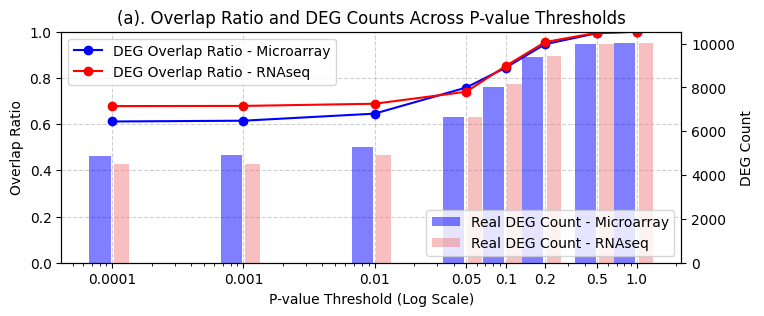

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Function to compute overlap ratio at different p-value thresholds
def compute_overlap_ratio(p_values1, p_values2, thresholds):
    overlap_ratios = []
    real_deg_counts=[]
    
    for threshold in thresholds:
        # Count values below threshold in each list
        set1 = set(np.where(np.array(p_values1) <= threshold)[0])
        set2 = set(np.where(np.array(p_values2) <= threshold)[0])

        # Compute overlap ratio: intersection size / union size
        if len(set1.union(set2)) > 0:
            overlap_ratio = len(set1.intersection(set2)) / len(set1.union(set2))
        else:
            overlap_ratio = 0

        overlap_ratios.append(overlap_ratio)
        real_deg_counts.append(len(set1))
        
    return overlap_ratios, real_deg_counts

# Define meaningful p-value thresholds (log scale)
thresholds = np.array([0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1])

# Compute overlap trend
overlap_ratios, real_deg_counts = compute_overlap_ratio(p_microarray, p_microarray_fake, thresholds)
overlap_ratios2, real_deg_counts2 = compute_overlap_ratio(p_rnaseq, p_rnaseq_fake, thresholds)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot the first two as line plots
ax1.plot(thresholds, overlap_ratios, marker='o', linestyle='-', color='b', label="DEG Overlap Ratio - Microarray")
ax1.plot(thresholds, overlap_ratios2, marker='o', linestyle='-', color='r', label="DEG Overlap Ratio - RNAseq")

# Set x-axis to log scale
ax1.set_xscale("log")
ax1.set_xticks(thresholds)
ax1.set_xticklabels([str(t) for t in thresholds])

# Labels for primary y-axis
ax1.set_xlabel("P-value Threshold (Log Scale)")
ax1.set_ylabel("Overlap Ratio")
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle="--", alpha=0.6)

# Create secondary y-axis
ax2 = ax1.twinx()

# Plot bar charts on the secondary y-axis
bar_width = thresholds*0.3  # Adjust width for better readability
ax2.bar(thresholds-0.6*bar_width, real_deg_counts, width=bar_width, color='blue', alpha=0.5, label="Real DEG Count - Microarray")
ax2.bar(thresholds+0.6*bar_width, real_deg_counts2, width=bar_width, color='lightcoral', alpha=0.5, label="Real DEG Count - RNAseq")

# Labels for secondary y-axis
ax2.set_ylabel("DEG Count")

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="lower right")

plt.title("(a). Overlap Ratio and DEG Counts Across P-value Thresholds")
plt.show()

## Stress Tests added code

In [75]:
import numpy as np
import pandas as pd
from scipy import stats
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import random

# ---------- Utilities ----------
def bh_fdr(pvals: np.ndarray):
    """Benjamini–Hochberg FDR for a 1D array; returns q-values in original order."""
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n+1)
    q = (p[order] * n) / ranks
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = q
    return out

def cohen_d(x, y):
    """Vectorized Cohen's d across columns (samples x genes)."""
    n1 = x.shape[0]
    n2 = y.shape[0]
    mean1 = np.nanmean(x, axis=0)
    mean2 = np.nanmean(y, axis=0)
    var1 = np.nanvar(x, axis=0, ddof=1)
    var2 = np.nanvar(y, axis=0, ddof=1)
    # pooled SD with Bessel correction
    s = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    d = (mean1 - mean2) / np.where(s==0, np.nan, s)
    return d

def _align_groups(data: pd.DataFrame, labels: pd.Series):
    """Align samples and return case/control matrices sharing the same gene order."""
    
    labels = labels.loc[data.index].astype(float)
    mask_pos = labels == 1
    mask_neg = labels == 0

    X_pos = data.loc[mask_pos].to_numpy()
    X_neg = data.loc[mask_neg].to_numpy()
    return X_pos, X_neg, mask_pos.sum(), mask_neg.sum()

def differential_expression(data: pd.DataFrame, labels: pd.Series):
    """
    Welch t-test (unequal variances), BH-FDR, Cohen's d, and mean difference.
    Returns DataFrame indexed by gene.
    """
    X_pos, X_neg, n_pos, n_neg = _align_groups(data, labels)
    # Welch t-test (vectorized): compute per-gene stats
    m1 = np.nanmean(X_pos, axis=0); v1 = np.nanvar(X_pos, axis=0, ddof=1)
    m0 = np.nanmean(X_neg, axis=0); v0 = np.nanvar(X_neg, axis=0, ddof=1)
    t_num = m1 - m0
    t_den = np.sqrt(v1/n_pos + v0/n_neg)
    t_stat = t_num / np.where(t_den==0, np.nan, t_den)

    # Welch-Satterthwaite df
    df_num = (v1/n_pos + v0/n_neg)**2
    df_den = (v1**2)/((n_pos**2)*(n_pos-1)) + (v0**2)/((n_neg**2)*(n_neg-1))
    dof = df_num / np.where(df_den==0, np.nan, df_den)

    # two-sided p
    p = 2*stats.t.sf(np.abs(t_stat), df=np.nan_to_num(dof, nan=1e6))
    q = bh_fdr(np.nan_to_num(p, nan=1.0))
    d = cohen_d(X_pos, X_neg)
    logFC = m1 - m0

    res = pd.DataFrame({
        't': t_stat, 'p': p, 'q': q, 'cohen_d': d, 'logFC': logFC
    }, index=data.columns)
    # Rank for enrichment: use |d| as a stable magnitude + keep sign separately if needed
    res['rank_stat'] = np.abs(res['cohen_d'])
    res.sort_values('rank_stat', ascending=False, inplace=False)
    return res

def top_overlap_curve(stat1: pd.Series, stat2: pd.Series, thresholds=(0.01, 0.02, 0.05, 0.1, 0.2)):
    """Compute Jaccard overlap across FDR thresholds for two q-value series aligned by gene."""
    thresholds = list(thresholds)
    jac = []
    counts = []
    for thr in thresholds:
        s1 = set(stat1.index[stat1.values <= thr])
        s2 = set(stat2.index[stat2.values <= thr])
        u = s1 | s2
        i = s1 & s2
        jac.append(len(i) / len(u) if len(u) else 0.0)
        counts.append(len(s1))
    return thresholds, jac, counts

# ---------- Gene set infrastructure ----------
def load_gmt(gmt_path: str):
    """
    Load a GMT file into {set_name: set(genes)}.
    Lines are: name  description  gene1  gene2 ...
    """
    gs = {}
    if gmt_path is None:
        return gs
    for line in Path(gmt_path).read_text().strip().splitlines():
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            gs[parts[0]] = set(parts[2:])
    return gs

def gene_set_enrichment(effect_df: pd.DataFrame, gene_sets: dict, how='abs_d'):
    """
    Simple, fast set-level enrichment using t-test on |effect size| vs background.
    Returns per-set dataframe with t, p, q, and rank.
    """
    gene_to_stat = effect_df['cohen_d'].astype(float)
    # working vector (absolute or signed)
    if how == 'abs_d':
        vec = np.abs(gene_to_stat)
    elif how == 'signed_d':
        vec = gene_to_stat
    else:
        raise ValueError("how must be 'abs_d' or 'signed_d'")

    vec = vec.dropna()
    all_genes = set(vec.index)
    rows = []
    for name, members in gene_sets.items():
        g = list(all_genes & set(members))
        if len(g) < 5:  # too small to be stable
            continue
        x = vec.loc[g].values
        y = vec.loc[list(all_genes - set(g))].values
        t, p = stats.ttest_ind(x, y, equal_var=False)
        rows.append((name, len(g), t, p, np.nanmean(x), np.nanmean(y)))
    if not rows:
        return pd.DataFrame(columns=['set', 'k', 't', 'p', 'q', 'mean_in', 'mean_out', 'rank'])
    df = pd.DataFrame(rows, columns=['set', 'k', 't', 'p', 'mean_in', 'mean_out'])
    df['q'] = bh_fdr(df['p'].values)
    df.sort_values('q', inplace=True)
    df['rank'] = np.arange(1, len(df)+1)
    return df

def spearman_rank_corr(df_real, df_syn):
    """
    Correlate pathway ranks between two enrichment tables.
    Uses ranks (with tie-breaks handled upstream) to avoid constant-vector NaNs.
    """
    if df_real is None or df_syn is None or len(df_real)==0 or len(df_syn)==0:
        return np.nan, np.nan

    # ensure required columns
    for df_name, df in (("real", df_real), ("syn", df_syn)):
        if not {"set","rank"}.issubset(df.columns):
            raise ValueError(f"enrichment table ({df_name}) must have columns ['set','rank'].")

    common = set(df_real["set"]) & set(df_syn["set"])
    if len(common) < 3:
        return np.nan, np.nan

    idx = sorted(common)  # <-- list, not set
    a = df_real.set_index("set").loc[idx]["rank"]
    b = df_syn.set_index("set").loc[idx]["rank"]

    # lower rank = more enriched → negate so larger = better for correlation
    rho, p = stats.spearmanr(-a.to_numpy(), -b.to_numpy())
    return rho, p

def gene_set_preservation_permutation(effect_real, effect_syn, gene_sets, B=1000, how='abs_d', random_seed=3):
    """
    Build a null for rank concordance by permuting gene-set membership in the SYNTHETIC side.
    Returns observed rho, null distribution, and p-value.
    """
    random.seed(random_seed)
    np.random.seed(random_seed)
    df_r = gene_set_enrichment(effect_real, gene_sets, how=how)
    df_s = gene_set_enrichment(effect_syn,  gene_sets, how=how)
    obs_rho, _ = spearman_rank_corr(df_r, df_s)

    # universe = all genes that appear in effect tables
    universe = set(effect_syn.index) & set(effect_real.index)
    universe = list(universe)

    null = []
    for _ in range(B):
        perm_syn_sets = permute_gene_sets_once(gene_sets, universe)
        df_perm = gene_set_enrichment(effect_syn, perm_syn_sets, how=how)
        rho, _ = spearman_rank_corr(df_r, df_perm)
        if np.isfinite(rho):
            null.append(rho)
    null = np.array(null)
    p = (np.sum(null >= obs_rho) + 1.0) / (len(null) + 1.0)  # one-sided: observed >= null
    return obs_rho, null, p, df_r, df_s

def topK_overlap(a_df, b_df, K=20):
    """Jaccard overlap of top-K gene sets ranked by q (or rank)."""
    get_top = lambda df: set(df.sort_values('q' if 'q' in df else 'rank').head(K)['set'])
    A = get_top(a_df); B = get_top(b_df)
    return len(A & B) / len(A | B) if len(A | B) else 0.0

In [52]:
import numpy as np
import pandas as pd

# ---------- Load your data (you already did the CSVs) ----------
df_ma_real  = pd.read_csv('./results/NB_v1/NB_50_ep400_0/Microarray_real.csv', index_col=0)
df_ma_fake  = pd.read_csv('./results/NB_v1/NB_50_ep400_0/Microarray_fake.csv', index_col=0)
df_rs_real  = pd.read_csv('./results/NB_v1/NB_50_ep400_0/RNAseq_real.csv', index_col=0)
df_rs_fake  = pd.read_csv('./results/NB_v1/NB_50_ep400_0/RNAseq_fake.csv', index_col=0)

df_endpoint = pd.read_csv('datasets/NB/SEQC_NB_249_ValidationSamples_ClinicalInfo_20121128.txt',sep="\t",index_col=0)
label_col = 'D_FAV_All'

# 1) standardize the label column to numeric, coercing bad strings to NaN
labels_raw = (
    pd.to_numeric(df_endpoint[label_col], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# 2) align labels to the samples you actually have in all 4 matrices
common_samples = (
    df_ma_real.index
      .intersection(df_ma_fake.index)
      .intersection(df_rs_real.index)
      .intersection(df_rs_fake.index)
)
labels = labels_raw.reindex(common_samples)

# 3) keep only rows with a valid label, and subset all matrices to the same rows
keep_idx = labels.index[labels.notna()]
labels = labels.loc[keep_idx].astype(int)   # safe now

df_ma_real = df_ma_real.loc[keep_idx]
df_ma_fake = df_ma_fake.loc[keep_idx]
df_rs_real = df_rs_real.loc[keep_idx]
df_rs_fake = df_rs_fake.loc[keep_idx]

In [53]:
df_gene_ref = pd.read_csv('datasets/NB/GPL16876-29646.txt',sep='\t', comment="#")
df_gene_ref.head()
ref_pool={}
for ind, d in df_gene_ref.iterrows():
    ref_pool[d['Agilent_Probe_Name']] = d['GeneSymbol']
df_gene = pd.read_csv('datasets/NB/NBT_1ma_1ngs.txt', sep="\t")
df_gene['GeneSymbol'] = [ref_pool.get(x,'') for x in df_gene['MA_ID']]
df_ma_real.columns = df_gene['GeneSymbol'].str.upper()
df_ma_fake.columns = df_gene['GeneSymbol'].str.upper()
df_rs_real.columns = df_gene['GeneSymbol'].str.upper()
df_rs_fake.columns = df_gene['GeneSymbol'].str.upper()

In [54]:
# Ensure all four matrices share the same sample order and gene universe
def _restrict(df, idx, cols):
    return df.loc[idx, cols].copy()

common_samples = df_ma_real.index.intersection(df_ma_fake.index).intersection(
                 df_rs_real.index).intersection(df_rs_fake.index)
common_genes = df_ma_real.columns.intersection(df_ma_fake.columns).intersection(
               df_rs_real.columns).intersection(df_rs_fake.columns)

df_ma_real = _restrict(df_ma_real, common_samples, common_genes)
df_ma_fake = _restrict(df_ma_fake, common_samples, common_genes)
df_rs_real = _restrict(df_rs_real, common_samples, common_genes)
df_rs_fake = _restrict(df_rs_fake, common_samples, common_genes)
labels = labels.loc[common_samples]

# ---------- DEG analysis with effect sizes ----------
deg_ma_real = differential_expression(df_ma_real, labels)
deg_ma_fake = differential_expression(df_ma_fake, labels)
deg_rs_real = differential_expression(df_rs_real, labels)
deg_rs_fake = differential_expression(df_rs_fake, labels)

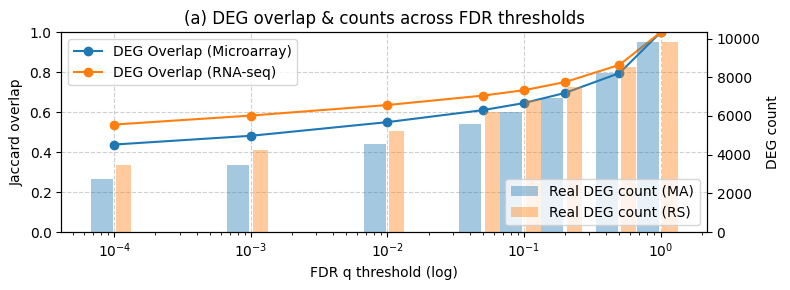

In [55]:
# Keep your overlap curve (switch to q thresholds)
q_thr = np.array([1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.2, 0.5, 1.0])
thr, jac_MA, n_deg_MA = top_overlap_curve(deg_ma_real['q'], deg_ma_fake['q'], q_thr)
thr, jac_RS, n_deg_RS = top_overlap_curve(deg_rs_real['q'], deg_rs_fake['q'], q_thr)

fig, ax1 = plt.subplots(figsize=(8,3))
ax1.plot(thr, jac_MA, marker='o', label="DEG Overlap (Microarray)")
ax1.plot(thr, jac_RS, marker='o', label="DEG Overlap (RNA-seq)")
ax1.set_xscale("log"); ax1.set_xlabel("FDR q threshold (log)"); ax1.set_ylabel("Jaccard overlap"); ax1.set_ylim(0,1)
ax1.grid(True, linestyle="--", alpha=0.6)
ax2 = ax1.twinx()
thr = np.asarray(thr, dtype=float)
bw = thr*0.3
ax2.bar(thr-0.6*bw, n_deg_MA, width=bw, alpha=0.4, label="Real DEG count (MA)")
ax2.bar(thr+0.6*bw, n_deg_RS, width=bw, alpha=0.4, label="Real DEG count (RS)")
ax2.set_ylabel("DEG count")
ax1.legend(loc="upper left"); ax2.legend(loc="lower right")
plt.title("(a) DEG overlap & counts across FDR thresholds")
plt.tight_layout()

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------- 1) Load GMT and filter to your gene universe --------
gmt_path = "datasets/h.all.v2025.1.Hs.symbols.gmt"  # <- use the exact filename you downloaded
if not Path(gmt_path).exists():
    raise FileNotFoundError(
        f"{gmt_path} not found. Use the actual MSigDB file on disk, e.g. "
        f"'datasets/h.all.v2024.1.Hs.symbols.gmt'"
    )

gene_sets_raw = load_gmt(gmt_path)

# Genes present in *all* four matrices
universe = set(df_ma_real.columns)

# Intersect each set with your universe and keep only sets with >=5 genes
gene_sets = {k: (set(v) & universe) for k, v in gene_sets_raw.items()}
gene_sets = {k: v for k, v in gene_sets.items() if len(v) >= 5}

print(f"Loaded {len(gene_sets_raw)} Hallmark sets; {len(gene_sets)} have ≥5 genes in your data.")

if len(gene_sets) < 5:
    raise ValueError(
        "Too few usable gene sets after filtering. "
        "Check that your gene identifiers (HGNC symbols) match the GMT, or use a different GMT library."
    )

# -------- 2) Sanity-check DE frames --------
needed = {"q", "cohen_d"}
for name, df in {
    "deg_ma_real": deg_ma_real,
    "deg_ma_fake": deg_ma_fake,
    "deg_rs_real": deg_rs_real,
    "deg_rs_fake": deg_rs_fake,
}.items():
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{name} is missing columns {missing}. "
                         "Make sure you computed DE with the updated differential_expression() helper.")


In [ ]:
obs_rho_MA, null_MA, p_MA, enr_MA_real, enr_MA_fake = gene_set_preservation_permutation(
    deg_ma_real, deg_ma_fake, gene_sets, B=1000, how='abs_d', random_seed=7
)
obs_rho_RS, null_RS, p_RS, enr_RS_real, enr_RS_fake = gene_set_preservation_permutation(
    deg_rs_real, deg_rs_fake, gene_sets, B=1000, how='abs_d', random_seed=7
)


[MA] Rank concordance (Spearman) real vs synthetic: rho=0.781, perm-p=0.000999 (Nnull=1000)
[RS] Rank concordance (Spearman) real vs synthetic: rho=0.790, perm-p=0.000999 (Nnull=1000)


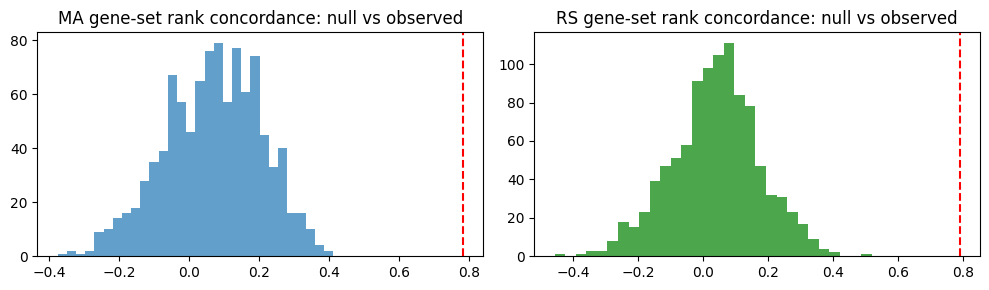

In [69]:
print(f"[MA] Rank concordance (Spearman) real vs synthetic: rho={np.nan_to_num(obs_rho_MA):.3f}, perm-p={p_MA:.4g} (Nnull={len(null_MA)})")
print(f"[RS] Rank concordance (Spearman) real vs synthetic: rho={np.nan_to_num(obs_rho_RS):.3f}, perm-p={p_RS:.4g} (Nnull={len(null_RS)})")

# Plot nulls only if we have enough draws and finite observed rhos
if len(null_MA) >= 5 and np.isfinite(obs_rho_MA):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].hist(null_MA, bins=30, alpha=0.7); ax[0].axvline(obs_rho_MA, linestyle='--',color='red')
    ax[0].set_title("MA gene-set rank concordance: null vs observed")
    if len(null_RS) >= 5 and np.isfinite(obs_rho_RS):
        ax[1].hist(null_RS, bins=30, alpha=0.7,color='green'); ax[1].axvline(obs_rho_RS, linestyle='--',color='red')
        ax[1].set_title("RS gene-set rank concordance: null vs observed")
    plt.tight_layout()

In [86]:
df_ma_real.head()

GeneSymbol,CXORF43,SLCO1B3,ANKS3,C11ORF82,CYP27A1,FLJ11506,AIG1,CCRL1,RAB40A,ZNF420,...,TINF2,HHIP,ELAVL2,PSMC3,KIF26A,TMEM125,FMNL2,NR1D2,C16ORF14,MCTP2
SEQC_NB001,-0.032230,-1.023344,1.025362,0.397966,-0.433662,1.328673,1.186446,-0.039581,0.073880,0.244872,...,1.549524,-0.729302,0.250306,1.579568,0.680502,0.094655,0.740909,0.235284,1.213294,-1.175798
SEQC_NB002,0.120975,-1.051824,1.162057,0.283142,-0.173593,1.354331,1.121344,-0.903685,0.098395,0.243455,...,1.548657,-0.653592,0.228744,1.390938,0.372778,-0.110642,1.036498,0.092921,1.401544,-0.880078
SEQC_NB005,0.144272,-1.806516,1.335013,0.537258,-0.416042,1.285227,1.127031,-0.762777,0.097137,0.222339,...,1.444306,-0.516792,-0.173593,1.367123,1.640799,-0.182136,1.044545,0.352843,1.674677,-1.552577
SEQC_NB006,0.242350,-1.106041,1.066612,0.605025,-0.579533,1.266814,1.000331,-0.618282,0.116246,0.282118,...,1.560490,-0.640376,0.004758,1.340913,1.389179,-0.055064,0.889523,0.032970,1.070691,-1.325618
SEQC_NB010,0.266097,-1.431304,1.189326,0.499215,-0.626223,1.219368,1.251433,-0.767769,0.106929,0.476972,...,1.336649,0.324160,0.229988,1.347338,1.514016,-0.281312,1.034491,0.292095,1.371892,-1.472035


In [89]:
import numpy as np
import pandas as pd
from scipy import stats

# --- utilities ---
def bh_fdr(pvals: np.ndarray):
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(np.nan_to_num(p, nan=np.inf))
    ranks = np.arange(1, n+1)
    q = (p[order] * n) / ranks
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q, dtype=float)
    out[order] = q
    # put back NaNs where p was NaN
    out[~np.isfinite(p)] = np.nan
    return out

def _clean_align_labels(labels: pd.Series, idx):
    # numeric, drop inf, keep only 0/1, aligned to idx
    lab = pd.to_numeric(labels, errors="coerce").replace([np.inf, -np.inf], np.nan)
    lab = lab.reindex(idx)
    mask_valid = lab.isin([0, 1])
    return lab.where(mask_valid)

# --- NEW DEG function (Welch, per-gene counts) ---
def deg_welch(data: pd.DataFrame, labels: pd.Series):
    """
    Differential expression with Welch's t-test (per-gene n and variance),
    BH-FDR, Hedges' g (bias-corrected Cohen's d), and mean difference (logFC).
    Returns a DataFrame indexed by gene.
    
    data:   samples x genes (rows = samples)
    labels: Series indexed by samples, values {0,1}; NaNs are dropped.
    """
    # 1) align & filter rows with valid labels
    labels = _clean_align_labels(labels, data.index)
    keep = labels.notna()
    if keep.sum() < 3:
        raise ValueError("Not enough labeled samples after dropping NaNs.")
    data = data.loc[keep]
    labels = labels.loc[keep].astype(int)

    # 2) split into arrays (handle NaNs per gene)
    X1 = data.loc[labels == 1].to_numpy(dtype=float)  # positive class
    X0 = data.loc[labels == 0].to_numpy(dtype=float)  # negative class

    # per-gene valid counts
    n1 = np.sum(np.isfinite(X1), axis=0).astype(float)
    n0 = np.sum(np.isfinite(X0), axis=0).astype(float)

    # means/vars ignoring NaNs
    m1 = np.nanmean(X1, axis=0)
    m0 = np.nanmean(X0, axis=0)
    v1 = np.nanvar(X1, axis=0, ddof=1)
    v0 = np.nanvar(X0, axis=0, ddof=1)

    # Guard: if a group has <2 valid samples for a gene, variance is NaN → set to 0 and mark counts
    v1 = np.where(n1 >= 2, v1, 0.0)
    v0 = np.where(n0 >= 2, v0, 0.0)

    # 3) Welch t-statistic (with small ridge for stability)
    eps = 1e-12
    se2 = v1 / np.clip(n1, 1.0, None) + v0 / np.clip(n0, 1.0, None)
    se = np.sqrt(np.maximum(se2, eps))
    t_stat = (m1 - m0) / se

    # Welch-Satterthwaite df (per gene)
    with np.errstate(invalid='ignore', divide='ignore'):
        df_num = se2**2
        df_den = (v1**2) / (np.clip(n1, 2, None)**2 * np.clip(n1 - 1, 1, None)) + \
                 (v0**2) / (np.clip(n0, 2, None)**2 * np.clip(n0 - 1, 1, None))
        dof = df_num / np.where(df_den == 0, np.nan, df_den)

    # two-sided p-values
    p = 2 * stats.t.sf(np.abs(t_stat), df=np.nan_to_num(dof, nan=1e6))
    q = bh_fdr(p)

    # 4) Effect size: Hedges' g (bias-corrected Cohen's d) with pooled SD
    # pooled SD (unbiased, per gene)
    sp2 = ((np.clip(n1, 2, None)-1) * v1 + (np.clip(n0, 2, None)-1) * v0) / \
          np.clip((np.clip(n1, 2, None) + np.clip(n0, 2, None) - 2), 1.0, None)
    sp = np.sqrt(np.maximum(sp2, 0.0))
    d = (m1 - m0) / np.where(sp == 0, np.nan, sp)

    # small-sample correction J
    N = np.clip(n1, 1, None) + np.clip(n0, 1, None)
    J = 1.0 - 3.0 / (4.0 * np.maximum(N, 3.0) - 9.0)
    hedges_g = d * J

    # 5) Assemble results
    res = pd.DataFrame({
        "t": t_stat,
        "p": p,
        "q": q,
        "cohen_d": hedges_g,          # bias-corrected
        "logFC": (m1 - m0),
        "n_pos": n1,
        "n_neg": n0
    }, index=data.columns)

    # rank statistic for enrichment (always finite)
    rank_stat = np.abs(hedges_g)
    rank_stat = np.nan_to_num(rank_stat, nan=0.0, posinf=0.0, neginf=0.0)
    res["rank_stat"] = rank_stat

    # clean impossible values
    res.replace([np.inf, -np.inf], np.nan, inplace=True)
    return res

def bootstrap_pathway_rank_stability(data_real, data_syn, labels, gene_sets, B=200, frac=0.8, how='abs_d', K_list=(10,20,50)):
    """
    Bootstrap samples within each platform, recompute pathway ranks, and summarize stability.
    Returns distributions of (Spearman rho, Kendall tau, and Top-K overlaps).
    """
    idx = data_real.index
    labels = labels.loc[idx]

    rhos, taus = [], []
    topk = {K: [] for K in K_list}
    n = len(idx)

    for _ in range(B):
        boot_idx = np.random.choice(idx, size=int(frac*n), replace=True)
        lab_b = labels.loc[boot_idx]
        de_r = deg_welch(data_real.loc[boot_idx, :], lab_b)
        de_s = deg_welch(data_syn.loc[boot_idx,  :], lab_b)
        enr_r = gene_set_enrichment(de_r, gene_sets, how=how)
        enr_s = gene_set_enrichment(de_s, gene_sets, how=how)

        rho, _ = spearman_rank_corr(enr_r, enr_s)
        rhos.append(rho)

        # Kendall tau over shared sets
        common = list(set(enr_r['set']) & set(enr_s['set']))
        if common:
            ar = enr_r.set_index('set').loc[common]['rank']
            br = enr_s.set_index('set').loc[common]['rank']
            tau, _ = stats.kendalltau(ar, br)
        else:
            tau = np.nan
        taus.append(tau)

        for K in K_list:
            topk[K].append(topK_overlap(enr_r, enr_s, K=K))

    return np.array(rhos), np.array(taus), {K: np.array(v) for K, v in topk.items()}

In [ ]:
# -------- 4) Pathway rank stability (bootstrap) --------
rhos_MA, taus_MA, topk_MA = bootstrap_pathway_rank_stability(
    df_ma_real, df_ma_fake, labels, gene_sets, B=200, frac=0.8, how='abs_d', K_list=(10, 20, 50)
)
rhos_RS, taus_RS, topk_RS = bootstrap_pathway_rank_stability(
    df_rs_real, df_rs_fake, labels, gene_sets, B=200, frac=0.8, how='abs_d', K_list=(10, 20, 50)
)


[MA] ρ bootstrap mean=0.746 (sd 0.072), 95% CI [0.578,0.838] | perm p=0.000999, Glass Δ=4.94
[RS] ρ bootstrap mean=0.774 (sd 0.055), 95% CI [0.651,0.870] | perm p=0.000999, Glass Δ=5.40


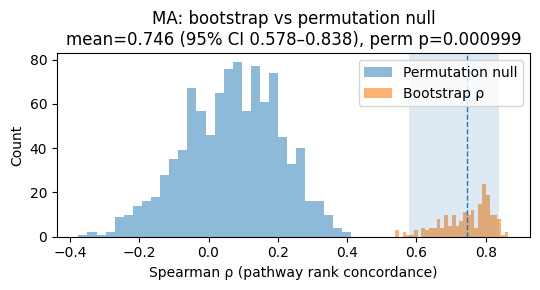

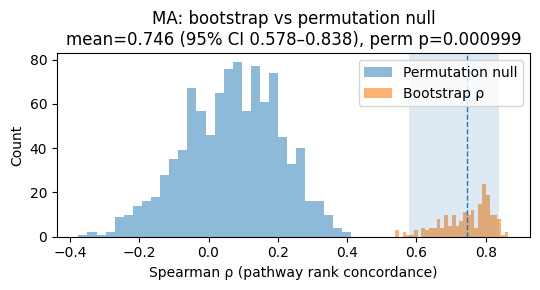

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from math import isnan

def ci95(x):
    x = np.asarray(x); x = x[np.isfinite(x)]
    if x.size == 0: return (np.nan, np.nan, np.nan)
    return (np.nanmean(x), np.nanstd(x, ddof=1), 
            np.nanpercentile(x, 2.5), np.nanpercentile(x, 97.5))

def perm_pvalue(null, stat, side="greater"):
    null = np.asarray(null); null = null[np.isfinite(null)]
    if null.size == 0 or not np.isfinite(stat): return np.nan
    if side == "greater":
        return (np.sum(null >= stat) + 1.0) / (null.size + 1.0)
    elif side == "less":
        return (np.sum(null <= stat) + 1.0) / (null.size + 1.0)
    else:
        # two-sided via symmetric doubling
        p1 = (np.sum(null >= stat) + 1.0) / (null.size + 1.0)
        p2 = (np.sum(null <= stat) + 1.0) / (null.size + 1.0)
        return 2*min(p1, p2)

def glass_delta(stat, null):
    null = np.asarray(null); null = null[np.isfinite(null)]
    if null.size < 2 or not np.isfinite(stat): return np.nan
    return (stat - np.nanmean(null)) / np.nanstd(null, ddof=1)

# ----- Spearman ρ: bootstrap CI + permutation p-value -----
mu_MA, sd_MA, lo_MA, hi_MA = ci95(rhos_MA)
mu_RS, sd_RS, lo_RS, hi_RS = ci95(rhos_RS)

p_perm_MA = perm_pvalue(null_MA, mu_MA, side="greater")
p_perm_RS = perm_pvalue(null_RS, mu_RS, side="greater")
g_MA = glass_delta(mu_MA, null_MA)
g_RS = glass_delta(mu_RS, null_RS)

print(f"[MA] ρ bootstrap mean={mu_MA:.3f} (sd {sd_MA:.3f}), 95% CI [{lo_MA:.3f},{hi_MA:.3f}] "
      f"| perm p={p_perm_MA:.3g}, Glass Δ={g_MA:.2f}")
print(f"[RS] ρ bootstrap mean={mu_RS:.3f} (sd {sd_RS:.3f}), 95% CI [{lo_RS:.3f},{hi_RS:.3f}] "
      f"| perm p={p_perm_RS:.3g}, Glass Δ={g_RS:.2f}")

# ----- Top-K Jaccard significance (Monte Carlo null + analytic baseline) -----
def jaccard_topk_mc(M, K, B=20000, rng=None):
    if rng is None: rng = np.random.default_rng(7)
    # Draw two random K-sets from M items; compute Jaccard = |∩| / |∪|
    ints = rng.hypergeometric(ngood=K, nbad=M-K, nsample=K, size=B)  # |intersection|
    j = ints / (2*K - ints)
    return j

def expected_jaccard_random(M, K):
    # E[|∩|]=K^2/M → E[J]= (K/M) / (2 - K/M)
    f = K / M
    return f / (2 - f)

def topk_sig_summary(enr_real, enr_syn, topk_dict, label):
    common = set(enr_real['set']) & set(enr_syn['set'])
    M = len(common)
    if M == 0:
        print(f"[{label}] No common sets to estimate Top-K null.")
        return
    for K in (10, 20, 50):
        if K > M: 
            print(f"[{label}] K={K} > M={M}, skipping.")
            continue
        emp = np.nanmean(topk_dict[K])
        null = jaccard_topk_mc(M, K, B=20000)
        p = perm_pvalue(null, emp, side="greater")
        ej = expected_jaccard_random(M, K)
        #print(f"[{label}] Top-{K} Jaccard: mean={emp:.3f}, "
        #      f"null_E≈{ej:.3f}, perm p={p:.3g}")

topk_sig_summary(enr_MA_real, enr_MA_fake, topk_MA, "MA")
topk_sig_summary(enr_RS_real, enr_RS_fake, topk_RS, "RS")

# ----- Publication-ready overlay plot: bootstrap ρ vs permutation null -----
def overlay_bootstrap_vs_null(null, boot, title):
    null = np.asarray(null); null = null[np.isfinite(null)]
    boot = np.asarray(boot); boot = boot[np.isfinite(boot)]
    if null.size == 0 or boot.size == 0:
        return
    mu, sd, lo, hi = ci95(boot)
    fig, ax = plt.subplots(figsize=(5.5, 3.0))
    ax.hist(null, bins=30, alpha=0.5, label="Permutation null")
    ax.hist(boot, bins=30, alpha=0.6, label="Bootstrap ρ")
    ax.axvline(mu, linestyle="--", linewidth=1)         # bootstrap mean
    ax.axvspan(lo, hi, alpha=0.15)                      # 95% CI band
    ax.set_title(title + f"\nmean={mu:.3f} (95% CI {lo:.3f}–{hi:.3f}), "
                         f"perm p={perm_pvalue(null, mu, 'greater'):.3g}")
    ax.set_xlabel("Spearman ρ (pathway rank concordance)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    return fig

overlay_bootstrap_vs_null(null_MA, rhos_MA, "MA: bootstrap vs permutation null")
# overlay_bootstrap_vs_null(null_RS, rhos_RS, "RS: bootstrap vs permutation null")


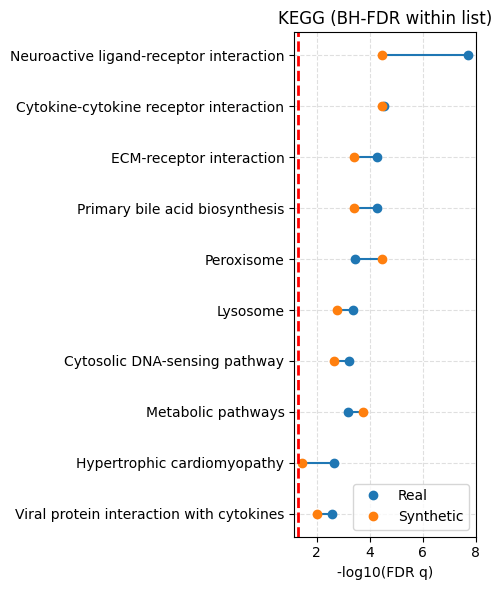

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bh_fdr(p):
    p = np.asarray(p, dtype=float)
    n = p.size
    order = np.argsort(np.nan_to_num(p, nan=np.inf))
    ranks = np.arange(1, n+1)
    q = (p[order] * n) / ranks
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q, dtype=float); out[order] = q
    out[~np.isfinite(p)] = np.nan
    return out

def slopegraph_pathways(df, top=10, alpha=0.05, title=None):
    # Compute FDR (preferably across *all* pathways tested, not just top 10)
    q_real = bh_fdr(df["p_real"].values)
    q_syn  = bh_fdr(df["p_syn"].values)
    plotdf = df.assign(q_real=q_real, q_syn=q_syn,
                       mlog_real=-np.log10(q_real),
                       mlog_syn=-np.log10(q_syn))
    # Order by real q and keep top N
    plotdf = plotdf.sort_values("q_real").head(top).copy()
    y = np.arange(len(plotdf))[::-1]

    fig, ax = plt.subplots(figsize=(5, 0.45*len(plotdf) + 1.5))
    # lines connecting real → synthetic
    for yi, xr, xs in zip(y, plotdf["mlog_real"], plotdf["mlog_syn"]):
        ax.hlines(yi, xr, xs, linewidth=1.5)
    # endpoints
    ax.plot(plotdf["mlog_real"], y, "o", label="Real")
    ax.plot(plotdf["mlog_syn"],  y, "o", label="Synthetic")

    # FDR=0.05 reference
    ax.axvline(-np.log10(alpha), linestyle="--", linewidth=2, color='red')

    ax.set_yticks(y)
    ax.set_yticklabels(plotdf["pathway"])
    ax.set_xlabel("-log10(FDR q)")
    ax.set_title(title or "Pathway enrichment: Real vs Synthetic")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    return fig, plotdf[["pathway","q_real","q_syn"]]


df = pd.DataFrame({
    "pathway": [
        "Neuroactive ligand-receptor interaction",
        "Cytokine-cytokine receptor interaction",
        "ECM-receptor interaction",
        "Primary bile acid biosynthesis",
        "Peroxisome",
        "Lysosome",
        "Cytosolic DNA-sensing pathway",
        "Metabolic pathways",
        "Hypertrophic cardiomyopathy",
        "Viral protein interaction with cytokines"
    ],
    "p_real": [2.030805e-09, 5.851565e-06, 1.798976e-05, 2.023614e-05, 1.762135e-04, 2.636357e-04, 4.042466e-04, 5.138101e-04, 2.008043e-03, 2.562905e-03],
    "p_syn":  [7.0e-06, 4.0e-06, 2.42e-04, 2.33e-04, 1.0e-05, 1.218e-03, 1.735e-03, 7.3e-05, 3.3866e-02, 8.863e-03],
})
fig, qtable = slopegraph_pathways(df, top=10, alpha=0.05, title="KEGG (BH-FDR within list)")

## Additional

In [61]:
## For fold change
def get_DEG(data):
    df_use = df_endpoint.loc[data.index, :]
    ind_pos = df_use[df_use['D_FAV_All'] == 1].index
    ind_neg = df_use[df_use['D_FAV_All'] == 0].index  
    
    data_pos = data.loc[ind_pos, :]
    data_neg = data.loc[ind_neg, :]

    # Compute log2 fold change with small constant to avoid division by zero
    mean_pos = data_pos.mean(axis=0) + 1e-6
    mean_neg = data_neg.mean(axis=0) + 1e-6
    log2_fold_change = mean_pos - mean_neg

    return log2_fold_change  # Series with feature names as index
    
fold_changes_microarray = get_DEG(df_ma_real)
fold_changes_microarray_fake = get_DEG(df_ma_fake)
fold_changes_rnaseq = get_DEG(df_rs_real)
fold_changes_rnaseq_fake = get_DEG(df_rs_fake)

In [69]:
fold_changes_microarray_50 = get_DEG(df_ma_real)
fold_changes_microarray_fake_50 = get_DEG(df_ma_fake)
fold_changes_rnaseq_50 = get_DEG(df_rs_real)
fold_changes_rnaseq_fake_50 = get_DEG(df_rs_fake)

In [75]:
df_ma_real[1:]

,0,1,2,3,4,5,6,7,8,9,...,10032,10033,10034,10035,10036,10037,10038,10039,10040,10041
SEQC_NB002,0.120975,-1.051824,1.162057,0.283142,-0.173593,1.354331,1.121344,-0.903685,0.098395,0.243455,...,1.548657,-0.653592,0.228744,1.390938,0.372778,-0.110642,1.036498,0.092921,1.401544,-0.880078
SEQC_NB004,0.336902,-1.300307,1.145869,0.470325,-0.107036,1.198274,1.293145,-0.835587,0.070359,0.294135,...,1.478371,-0.368158,0.150171,1.233211,1.697629,-0.013670,0.984136,0.277269,1.491321,-1.634314
SEQC_NB005,0.144272,-1.806516,1.335013,0.537258,-0.416042,1.285227,1.127031,-0.762777,0.097137,0.222339,...,1.444306,-0.516792,-0.173593,1.367123,1.640799,-0.182136,1.044545,0.352843,1.674677,-1.552577
SEQC_NB006,0.242350,-1.106041,1.066612,0.605025,-0.579533,1.266814,1.000331,-0.618282,0.116246,0.282118,...,1.560490,-0.640376,0.004758,1.340913,1.389179,-0.055064,0.889523,0.032970,1.070691,-1.325618
SEQC_NB007,0.032349,-1.718579,1.440920,0.563340,-0.438702,1.412361,1.548105,-0.335395,-0.149936,0.095462,...,1.598877,-0.329401,0.405735,1.388032,0.900057,-0.005730,0.778063,0.121200,1.172251,-0.893887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SEQC_NB493,0.022083,-1.415472,1.168548,0.226610,-0.246119,1.244842,1.362511,-0.771081,0.173791,0.235413,...,1.420025,-0.314197,0.778568,1.162386,1.717278,-0.522245,0.850754,0.132123,1.203174,-1.285479
SEQC_NB494,-0.159816,-1.381215,1.158949,0.089138,-0.126861,1.199992,1.389628,-0.678094,0.133177,-0.022007,...,1.381838,-0.568746,0.401303,1.202987,1.068175,-0.570544,0.908198,0.318019,1.228452,-1.367135
SEQC_NB496,0.085192,-1.255353,1.059846,0.308184,-0.362232,1.052067,1.317699,-0.509741,0.098733,0.016624,...,1.466936,-0.413803,0.230973,1.281974,1.450514,-0.248720,0.950079,0.171911,0.869122,-1.231440
SEQC_NB497,0.083050,-1.489699,1.151365,0.100826,0.060611,1.028972,1.393236,-0.544360,0.020688,0.264016,...,1.496979,-0.632657,0.690352,1.194202,1.273758,-0.235755,1.069187,0.204277,1.117852,-1.476294


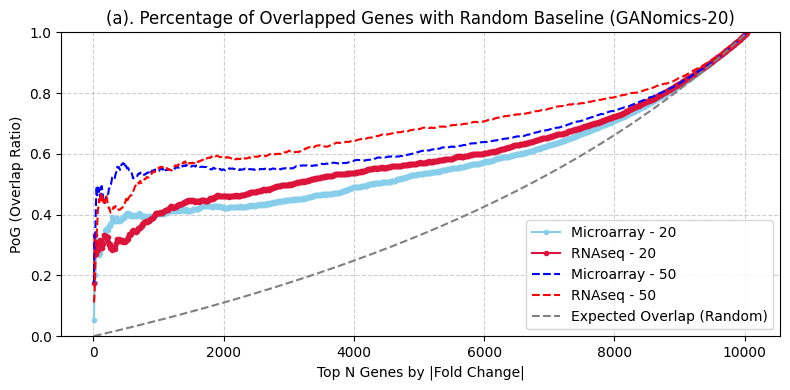

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def compute_pog(fold_changes1, fold_changes2, step=10):
    n_genes = len(fold_changes1)
    max_genes = (n_genes // step) * step
    pog_values = []
    random_baseline = []
    top_counts = []

    ranked1 = np.argsort(-np.abs(fold_changes1))
    ranked2 = np.argsort(-np.abs(fold_changes2))

    for top_n in range(step, max_genes + 1, step):
        top_set1 = set(ranked1[:top_n])
        top_set2 = set(ranked2[:top_n])

        intersection = len(top_set1 & top_set2)
        union = len(top_set1 | top_set2)
        jaccard = intersection / union if union > 0 else 0

        # Theoretical random baseline
        expected_jaccard = top_n / (2 * n_genes - top_n)

        pog_values.append(jaccard)
        random_baseline.append(expected_jaccard)
        top_counts.append(top_n)

    return top_counts, pog_values, random_baseline

# Example:
top_counts1, pog_micro, rand_baseline1 = compute_pog(fold_changes_microarray, fold_changes_microarray_fake)
top_counts2, pog_rnaseq, rand_baseline2 = compute_pog(fold_changes_rnaseq, fold_changes_rnaseq_fake)

top_counts1_50, pog_micro_50, rand_baseline1 = compute_pog(fold_changes_microarray_50, fold_changes_microarray_fake_50)
top_counts2_50, pog_rnaseq_50, rand_baseline2 = compute_pog(fold_changes_rnaseq_50, fold_changes_rnaseq_fake_50)


# Plot
plt.figure(figsize=(8, 4))
plt.plot(top_counts1, pog_micro, marker='.', label="Microarray - 20", color='#87CEEB') #'b'
plt.plot(top_counts2, pog_rnaseq, marker='.', label="RNAseq - 20", color='crimson') #'r'

plt.plot(top_counts1_50, pog_micro_50, linestyle='--', label="Microarray - 50", color='b')
plt.plot(top_counts2_50, pog_rnaseq_50, linestyle='--', label="RNAseq - 50", color='r')
plt.plot(top_counts1_50, rand_baseline1, linestyle='--', color='gray', label="Expected Overlap (Random)")

plt.xlabel("Top N Genes by |Fold Change|")
plt.ylabel("PoG (Overlap Ratio)")
plt.title("(a). Percentage of Overlapped Genes with Random Baseline (GANomics-20)")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
## Save the significant list of genes
threshold = 0.05
gene_name = pd.read_csv('./datasets/NB/NB_NGS_121.txt', sep="\t").index
# print(len(gene_name))
microarray = gene_name[p_microarray<threshold]
microarray_fake = gene_name[p_microarray_fake<threshold]
rnaseq = gene_name[p_rnaseq<threshold]
rnaseq_fake = gene_name[p_rnaseq_fake<threshold]

# os.system('mkdir ./results/DEG_lists_NBFav_50')
for d in ['microarray', 'microarray_fake', 'rnaseq', 'rnaseq_fake']:
    with open(f'./results/DEG_lists_NBFav_50/{d}.txt', 'w') as f:
        f.write('\n'.join([str(x) for x in eval(d)]))

In [46]:
with open(f'./results/DEG_lists_NBFav_50/background.txt', 'w') as f:
        f.write('\n'.join([str(x) for x in gene_name]))

In [ ]:
### Pathway analysis

In [63]:
df_path_rnaseq_real = pd.read_csv('./results/Enriched_Pathways_s20/KEGG_rnaseq_real.txt', sep="\t").fillna('')
df_path_rnaseq_fake = pd.read_csv('./results/Enriched_Pathways_s20/KEGG_rnaseq_fake.txt', sep="\t").fillna('')
df_path_rnaseq_fake = pd.read_csv('./results/Enriched_Pathways_s20/KEGG_rnaseq_fake.txt', sep="\t").fillna('')

In [64]:
sig_pathways = df_path_rnaseq_real.loc[:,['Term','PValue']]
sig_pathways.columns = ['Enriched KEGG Pathways', 'P-Value (Real Profile)', ]
sig_pathways['P-Value (Generated Profile)'] = ''
sig_pathways['Significance (Generated Profile)'] = ''
for ind, d in sig_pathways.iterrows():
    p_fake = df_path_rnaseq_fake[df_path_rnaseq_fake['Term']==d['Enriched KEGG Pathways']]
    if p_fake.shape[0] == 0:
        sig_pathways.loc[ind, 'Significance (Generated Profile)'] = 'No'
        continue
    else:
        p = p_fake['PValue'].values[0]
        sig_pathways.loc[ind, 'P-Value (Generated Profile)'] = p
        if float(p)<0.05:
            sig_pathways.loc[ind, 'Significance (Generated Profile)'] = 'Yes'
        else:
            sig_pathways.loc[ind, 'Significance (Generated Profile)'] = 'No'

In [65]:
sig_pathways.head(20)

,Enriched KEGG Pathways,P-Value (Real Profile),P-Value (Generated Profile),Significance (Generated Profile)
0,hsa01100:Metabolic pathways,7.656241e-07,0.000001,Yes
1,hsa00520:Amino sugar and nucleotide sugar meta...,8.245212e-05,0.000443,Yes
2,hsa04146:Peroxisome,3.109591e-04,0.00519,Yes
3,hsa04721:Synaptic vesicle cycle,1.909997e-03,0.010543,Yes
4,hsa00190:Oxidative phosphorylation,2.337973e-03,0.046577,Yes
5,hsa04080:Neuroactive ligand-receptor interaction,2.881526e-03,0.0,Yes
6,hsa02010:ABC transporters,9.227146e-03,0.022869,Yes
7,hsa03018:RNA degradation,1.087046e-02,0.101918,No
8,hsa03420:Nucleotide excision repair,1.144720e-02,0.080557,No
9,hsa04260:Cardiac muscle contraction,1.450924e-02,0.097466,No


In [58]:
sig_pathways.to_excel('./results/Enriched_Pathways_s50/Enriched_rnaseq_result.xlsx',index=None)